# 0. Plan And Notebook Roadmap

This notebook will compare LLM-generated critiques against the cleaned human critique reference for the same UI screens.

This is intentionally structured as a planning-first notebook scaffold. The markdown cells describe the full analysis design so the implementation can be added cleanly and in order later.


## 0.1 Goals

The notebook has four main goals:

1. Convert both the human reference comments and the LLM critiques into a comparable long-form structure where each row is one critique.
2. Compare the two sources at the **screen level** using `observed_issue` as the current matching field.
3. Build a conservative semantic-matching pipeline that combines embedding retrieval with OpenAI adjudication for uncertain pairs.
4. Summarize quantitative agreement, mismatch patterns, and guideline-reference usage in a reusable analysis workflow.


## 0.2 Scope

Current scope for this notebook version:

- Human reference source: `human_comments_exact_dedup.parquet`
- LLM source: critiques parquet outputs from the OpenAI inference pipeline
- Task subset: `all_tasks`
- Prompting setup: `zero_shot`
- Matching level: **screen level**, not task level
- Matching text: `observed_issue` only, for now

Planned later extension:

- Replace the human reference with `human_comments_semantic_dedup.parquet`
- Keep the rest of the notebook structure unchanged because both reference files can be standardized into the same shared comment schema


## 0.3 Why Screen-Level Matching

The matching should be performed within each `screen_id`, not within each `screen_task_id`.

Rationale:

- Human critiques for the same screen may appear under multiple tasks.
- LLM critiques may also surface issues that are screen-wide rather than tightly task-specific.
- Screen-level comparison better reflects whether the model identified the important visual or usability issues present on the interface.

The notebook will still keep `screen_task_id` in the data tables because it remains useful for traceability, filtering, and qualitative inspection.


## 0.4 Planned Data Structures

Two main long-form tables will be created using the same core schema.

### Shared core schema

Each row should retain:

- `comment_id`
- `source_type`
- `screen_id`
- `screen_task_id`
- `task`
- `app_category`
- `observed_issue`
- `expected_standard`
- `suggested_fix`
- `match_text`

### Optional human-side fields

- `missing_parts`
- `raw_text`
- `bounding_box`
- `comment_label`

### Optional LLM-side fields

- `guideline_reference`
- `model_name`


## 0.5 Matching Strategy

The comparison pipeline will follow a two-stage semantic matching design inspired by the workflow already used in `prepare_human_comments_reference.ipynb`, especially the logic around the embedding candidate stage and OpenAI review stage.

### Stage 1: Embedding retrieval

For all human-LLM critique pairs within the same `screen_id`:

- embed `observed_issue` using `SentenceTransformer("all-mpnet-base-v2")`
- compute cosine similarity for each within-screen pair
- use the similarity scores to identify:
  - strong likely matches
  - uncertain candidate matches
  - clear non-matches

### Stage 2: OpenAI adjudication

For uncertain candidate pairs only:

- send pairwise judgments to OpenAI
- use a conservative prompt and structured schema similar to the duplicate-review workflow in the reference-preparation notebook
- base the decision on whether the human and LLM critiques describe the same issue, one contains the other, partially overlap, or are different

### Final consolidation

Use the embedding scores and the OpenAI-reviewed decisions to build a final match table with:

- best available human match for each LLM critique
- whether each human critique is covered by any LLM critique
- similarity and decision metadata for auditability


## 0.6 Planned Evaluation Metrics

Because the comparison is semantic and screen-level, the notebook should prioritize coverage and alignment metrics over exact string equality.

Primary metrics:

- number of human critiques per screen
- number of LLM critiques per screen
- count difference between human and LLM critiques
- human coverage rate: proportion of human critiques matched by at least one LLM critique
- LLM alignment rate: proportion of LLM critiques matched to at least one human critique
- unmatched human critique rate
- unmatched LLM critique rate
- similarity score summaries for matched pairs

Secondary metrics:

- coverage by `app_category`
- relationship between human `missing_parts` and match success
- frequency of common issue themes if useful later
- guideline-reference coverage and frequency on the LLM side


## 0.7 Guideline Reference Analysis

The notebook should include a dedicated analysis of `guideline_reference` in the LLM critiques.

Questions to answer:

- How often does the model provide a guideline reference at all?
- Which guideline sources are cited most frequently?
- Are some guideline references associated with better human alignment?
- Do guideline-reference patterns vary by `app_category`?

This section can remain descriptive at first and become more analytical later once the base matching pipeline is complete.


## 0.8 Qualitative Analysis Plan

In addition to summary metrics, the notebook should include representative qualitative examples.

Suggested example groups:

- strong human-LLM matches
- partial overlaps
- human-only critiques missed by the model
- LLM-only critiques with no human counterpart
- cases where the issue is valid on both sides but expressed at different levels of granularity

These examples will help interpret the metric results and will likely be useful for thesis writing.


## 0.9 Planned Outputs

The notebook should save intermediate and final outputs so later sections do not need to be recomputed from scratch.

Suggested outputs:

- `human_comments_long.parquet`
- `llm_critiques_long.parquet`
- `screen_level_candidate_pairs.parquet`
- `embedding_similarity_pairs.parquet`
- `openai_reviewed_pairs.parquet`
- `final_comment_match_table.parquet`
- `screen_level_summary_metrics.parquet`
- `guideline_reference_summary.csv`


## 0.10 Implementation Order

The notebook will be implemented in the following order:

1. Imports and configuration
2. Load human and LLM sources
3. Run descriptive dataset checks
4. Build long-form critique tables
5. Construct screen-level candidate pairs
6. Run embedding similarity scoring
7. Prepare and review uncertain pairs with OpenAI
8. Build the final match table
9. Compute evaluation metrics
10. Analyze guideline references
11. Add qualitative examples
12. Save outputs


# 1. Imports And Configuration

This section will define the notebook dependencies, configuration constants, file paths, and model aliases.

It should include:

- standard analysis imports such as `pandas`, `numpy`, `matplotlib`, and `seaborn`
- notebook path setup for local utility imports
- constants for `TASK_SUBSET`, `PROMPTING_TYPE`, `STAGE`, and selected models
- paths to the cleaned dataset and critique result files
- any threshold constants used later for semantic matching and review-band selection


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import sys
sys.path.append('../')

from utils.comment_matching_utils import (
    build_standardized_human_comments_from_nested,
    build_standardized_llm_comments_from_nested,
)
from utils.data_setup import load_existing_responses
from utils.statistics_plots_analysis_utils import *

TASK_SUBSET = 'all_tasks'
PROMPTING_TYPE = 'zero_shot'
STAGE = 'critiques'
NUM_TRIALS = 1

MODEL_SHORT = {
    'GPT-5': 'gpt5',
    'Gemini-2.5': 'gemini2_5pro',
    'Claude-4': 'claude4',
    'Qwen-3': 'qwen3_vl',
}

selected_models = ['GPT-5']

# 2. Load Data

This section loads the human reference comments and the LLM critique outputs, then restricts both sides to the shared analysis base used downstream.


## 2.1 Load Human Reference

Load `human_comments_exact_dedup.parquet` and keep the columns needed for downstream comparison.

Expected fields at this stage:

- `screen_id`
- `app_category`
- `screen_task_id`
- `task`
- `comments`

This table remains in nested format initially and will be exploded later in Section 4.


In [2]:
dataset_dir = Path('../../data/dataset/cleaned_dataset')
human_reference_file = dataset_dir / 'human_comments_exact_dedup.parquet'
results_dir = Path(f'../results/{STAGE}/parquet')
results_file_base = f'{STAGE}-{{prompting_type}}-{TASK_SUBSET}-{{model_short}}-responses.parquet'

human_reference_columns = ['screen_id', 'app_category', 'screen_task_id', 'task', 'comments']

print('Human reference file:', human_reference_file)
print('Results directory:', results_dir.resolve())
print('Selected models:', selected_models)


Human reference file: ..\..\data\dataset\cleaned_dataset\human_comments_exact_dedup.parquet
Results directory: C:\Users\mahmo\OneDrive - The University of Western Ontario\Desktop\Western_University\Thesis\Project\code\results\critiques\parquet
Selected models: ['GPT-5']


In [3]:
experts_df = pd.read_parquet(human_reference_file, columns=human_reference_columns).copy()

experts_df['comments'] = experts_df['comments'].apply(
    lambda x: list(x) if isinstance(x, (list, np.ndarray, pd.Series)) else ([] if pd.isna(x) else x)
)

human_summary = pd.Series({
    'rows': len(experts_df),
    'unique_screens': experts_df['screen_id'].nunique(),
    'unique_screen_tasks': experts_df['screen_task_id'].nunique(),
    'rows_with_empty_comments': int(experts_df['comments'].apply(lambda x: len(x) == 0 if isinstance(x, list) else False).sum()),
    'total_nested_comments': int(experts_df['comments'].apply(lambda x: len(x) if isinstance(x, list) else 0).sum()),
})

display(human_summary.to_frame('value'))
experts_df.head(2)

,value
rows,1987
unique_screens,1000
unique_screen_tasks,1987
rows_with_empty_comments,0
total_nested_comments,7957


,screen_id,app_category,screen_task_id,task,comments
0,15,Health & Fitness,15_T01,Plan and Start Full Body Workouts,"[{'bounding_box': {'x_max': 0.40545597, 'x_min..."
1,15,Health & Fitness,15_T02,Tap on the Plus icon or explore the Workout Pl...,"[{'bounding_box': {'x_max': 0.10555714, 'x_min..."


## 2.2 Load LLM Critiques

Load the saved critiques parquet outputs from the OpenAI inference pipeline.

At this stage, the focus is on:

- selecting the current model or models for analysis
- parsing the `critiques` JSON payload if it is stored as a string
- verifying that the critique rows align to the expected `screen_id` and `screen_task_id`


In [ ]:
def parse_critiques_payload(value):
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        return json.loads(value)
    if value is None:
        return []
    if isinstance(value, float) and pd.isna(value):
        return []
    return value

def load_model_critiques(prompting_type, selected_models):
    model_dfs = {}

    for model_name in selected_models:
        model_short = MODEL_SHORT[model_name]
        results_file = results_dir / results_file_base.format(
            prompting_type=prompting_type,
            model_short=model_short,
        )

        df = load_existing_responses(
            results_file_path=results_file,
            uicrit_file=human_reference_file,
            num_trials=NUM_TRIALS,
            stage=STAGE,
        ).copy()

        if 'critiques' not in df.columns:
            raise KeyError(f"Expected 'critiques' column in {results_file}")

        df['critiques'] = df['critiques'].apply(parse_critiques_payload)
        df['num_llm_critiques'] = df['critiques'].apply(lambda x: len(x) if isinstance(x, list) else 0)

        model_dfs[model_name] = df

        print(f"{model_name}: {results_file.name} -> {df.shape[0]} rows | {df['screen_id'].nunique()} screens")

    return model_dfs

model_dfs = load_model_critiques(PROMPTING_TYPE, selected_models)
model_dfs[selected_models[0]].head(2)

GPT-5: critiques-zero_shot-all_tasks-gpt5-responses.parquet -> 2957 rows | 1000 screens


,screen_task_id,screen_id,task,critiques,num_llm_critiques
0,15_T01,15,Plan and Start Full Body Workouts,"[{'expected_standard': 'A clear, prominent pri...",10
1,15_T02,15,Tap on the Plus icon or explore the Workout Pl...,[{'expected_standard': 'Floating action button...,5


## 2.3 Restrict To Shared Analysis Rows

Before comparing content, restrict both sides to the common set of rows that are actually available for the current analysis run.

This section should confirm:

- number of shared screens
- number of shared screen-task rows
- whether any expected rows are missing on either side
- whether the current subset is complete enough for valid downstream analysis


In [5]:
key_cols = ['screen_id', 'screen_task_id']

model_key_frames = {
    model_name: df[key_cols].drop_duplicates().copy()
    for model_name, df in model_dfs.items()
}

common_keys_df = None
for model_name in selected_models:
    if common_keys_df is None:
        common_keys_df = model_key_frames[model_name].copy()
    else:
        common_keys_df = common_keys_df.merge(model_key_frames[model_name], on=key_cols, how='inner')

experts_df_shared = experts_df.merge(common_keys_df, on=key_cols, how='inner').copy()
shared_model_dfs = {
    model_name: df.merge(common_keys_df, on=key_cols, how='inner').copy()
    for model_name, df in model_dfs.items()
}

responses_df = shared_model_dfs[selected_models[0]].copy()

shared_summary_rows = []
shared_summary_rows.append({
    'dataset': 'human_reference_shared',
    'rows': len(experts_df_shared),
    'unique_screens': experts_df_shared['screen_id'].nunique(),
    'unique_screen_tasks': experts_df_shared['screen_task_id'].nunique(),
})

for model_name, df in shared_model_dfs.items():
    shared_summary_rows.append({
        'dataset': f'llm_shared::{model_name}',
        'rows': len(df),
        'unique_screens': df['screen_id'].nunique(),
        'unique_screen_tasks': df['screen_task_id'].nunique(),
    })

shared_summary_df = pd.DataFrame(shared_summary_rows)
display(shared_summary_df)

missing_human_keys = len(common_keys_df) - len(experts_df_shared[key_cols].drop_duplicates())
print('Common analysis keys:', len(common_keys_df))
print('Missing keys from human reference after filtering:', missing_human_keys)
print('Active analysis dataframe:', selected_models[0])

responses_df.head(2)

,dataset,rows,unique_screens,unique_screen_tasks
0,human_reference_shared,1987,1000,1987
1,llm_shared::GPT-5,2957,1000,2957


Common analysis keys: 2957
Missing keys from human reference after filtering: 970
Active analysis dataframe: GPT-5


,screen_task_id,screen_id,task,critiques,num_llm_critiques
0,15_T01,15,Plan and Start Full Body Workouts,"[{'expected_standard': 'A clear, prominent pri...",10
1,15_T02,15,Tap on the Plus icon or explore the Workout Pl...,[{'expected_standard': 'Floating action button...,5


# 3. Build Long-Form Critique Tables

This section converts both sources into critique-level tables so one row corresponds to one critique.

These long-form tables become the main inputs for the screen-level matching workflow later in the notebook.


## 3.1 Build `human_comments_long_df`

Explode the human `comments` list and standardize the result into the shared comment-level schema.

Keep the common core fields plus human-specific optional fields such as `missing_parts`, `raw_text`, `bounding_box`, and `comment_label`.


In [6]:
human_comments_long_df = build_standardized_human_comments_from_nested(
    experts_df_shared[['screen_id', 'app_category', 'screen_task_id', 'task', 'comments']].copy(),
    nested_comments_col='comments',
    comment_id_prefix='H',
)

human_long_summary = pd.Series({
    'rows': len(human_comments_long_df),
    'unique_screens': human_comments_long_df['screen_id'].nunique(),
    'unique_screen_tasks': human_comments_long_df['screen_task_id'].nunique(),
    'rows_with_missing_observed_issue': int(human_comments_long_df['observed_issue'].isna().sum()),
    'rows_with_nonempty_missing_parts': int(human_comments_long_df['missing_parts'].apply(len).gt(0).sum()),
})

display(human_long_summary.to_frame('value'))
human_comments_long_df.head(3)


,value
rows,7957
unique_screens,1000
unique_screen_tasks,1987
rows_with_missing_observed_issue,0
rows_with_nonempty_missing_parts,9


,human_comment_id,screen_id,app_category,screen_task_id,task,comment_label,missing_parts,expected_standard,observed_issue,suggested_fix,raw_text,bounding_box
0,HC_000001,15,Health & Fitness,15_T01,Plan and Start Full Body Workouts,Comment 1,[],the text’s visual treatment and formatting sho...,the text (Workouts) is small even when it is h...,increase font size and weight to make it look...,Comment 1 The expected standard is that the te...,NaN
1,HC_000002,15,Health & Fitness,15_T01,Plan and Start Full Body Workouts,Comment 2,[],the text and background colors used in the des...,text (Plans) is in light red color on white ba...,change colors to be more complementary to each...,Comment 2 The expected standard is that the te...,NaN
2,HC_000003,15,Health & Fitness,15_T01,Plan and Start Full Body Workouts,Comment 3,[],the design should make the most important info...,the back button size is small.,increase the back button size to make it visua...,Comment 3 The expected standard is that the de...,NaN


## 3.2 Build `llm_critiques_long_df`

Parse and explode the LLM `critiques` payload and standardize the result into the same shared comment-level schema.

Keep the common core fields plus LLM-specific optional fields such as `guideline_reference` and `model_name`.


In [ ]:
llm_long_frames = []

for model_name, df in shared_model_dfs.items():
    model_long_df = df[['screen_id', 'screen_task_id', 'task', 'critiques']].copy()
    model_long_df = model_long_df.merge(
        experts_df_shared[['screen_id', 'app_category']].drop_duplicates(),
        on='screen_id',
        how='left',
    )
    llm_long_frames.append(
        build_standardized_llm_comments_from_nested(
            model_long_df,
            nested_comments_col='critiques',
            comment_id_prefix='L',
            model_name=model_name,
            model_code=MODEL_SHORT[model_name],
        )
    )

llm_critiques_long_df = pd.concat(llm_long_frames, ignore_index=True) if llm_long_frames else pd.DataFrame()

llm_long_summary = pd.Series({
    'rows': len(llm_critiques_long_df),
    'unique_screens': llm_critiques_long_df['screen_id'].nunique(),
    'unique_screen_tasks': llm_critiques_long_df['screen_task_id'].nunique(),
    'rows_with_missing_observed_issue': int(llm_critiques_long_df['observed_issue'].isna().sum()),
    'rows_with_guideline_reference': int(llm_critiques_long_df['guideline_reference'].notna().sum()),
})

display(llm_long_summary.to_frame('value'))
llm_critiques_long_df.head(3)


,value
rows,17918
unique_screens,1000
unique_screen_tasks,2955
rows_with_missing_observed_issue,0
rows_with_guideline_reference,17917


,model_name,llm_comment_id,screen_id,screen_task_id,task,expected_standard,observed_issue,suggested_fix,guideline_reference
0,GPT-5,gpt5_LC_000001,15,15_T01,Plan and Start Full Body Workouts,"A clear, prominent primary action to start the...",The Full Body item shows only a checkmark and ...,Add a labeled Start Full Body button within th...,Nielsen Norman: Visibility of system status; M...
1,GPT-5,gpt5_LC_000002,15,15_T01,Plan and Start Full Body Workouts,Status/selection indicators should be unambigu...,The trailing checkmark beside Full Body lacks ...,Replace or accompany the checkmark with explic...,Nielsen Norman: Consistency and standards; Rec...
2,GPT-5,gpt5_LC_000003,15,15_T01,Plan and Start Full Body Workouts,Floating controls must not obscure content or ...,The floating + button overlaps the Lower Body ...,"Reposition the FAB with adequate insets, add b...",Apple Human Interface Guidelines — Layout — Sa...


In [8]:
human_screen_task_ids = set(human_comments_long_df["screen_task_id"].dropna().astype(str).unique())
llm_screen_task_ids = set(llm_critiques_long_df["screen_task_id"].dropna().astype(str).unique())

missing_in_llm = sorted(human_screen_task_ids - llm_screen_task_ids)
extra_in_llm = sorted(llm_screen_task_ids - human_screen_task_ids)

print("Human unique screen_task_id:", len(human_screen_task_ids))
print("LLM unique screen_task_id:", len(llm_screen_task_ids))
print("Missing in LLM:", len(missing_in_llm))
print("Extra in LLM:", len(extra_in_llm))

if missing_in_llm:
    display(
        human_comments_long_df[
            human_comments_long_df["screen_task_id"].astype(str).isin(missing_in_llm)
        ][["screen_id", "screen_task_id", "task", "app_category"]]
        .drop_duplicates()
        .sort_values(["screen_id", "screen_task_id"])
    )
else:
    print("All human screen_task_id values exist in the LLM table.")


Human unique screen_task_id: 1987
LLM unique screen_task_id: 2955
Missing in LLM: 0
Extra in LLM: 968
All human screen_task_id values exist in the LLM table.


# 4. Descriptive Analysis

This section will characterize the data before any semantic matching is attempted.

The goal is to understand scale, distribution, and obvious structural differences between the human and LLM critique sets.


## 4.1 High-Level Counts

Compute summary counts such as:

- number of rows on each side
- number of unique screens
- number of unique screen-task ids
- number of nested critiques before exploding
- number of missing or empty critique lists if present


In [9]:
analysis_high_level_counts = pd.DataFrame([
    {
        'dataset': 'human_reference_nested',
        'rows': len(experts_df_shared),
        'unique_screens': experts_df_shared['screen_id'].nunique(),
        'unique_screen_tasks': experts_df_shared['screen_task_id'].nunique(),
        'total_critiques': int(experts_df_shared['comments'].apply(lambda x: len(x) if isinstance(x, list) else 0).sum()),
        'rows_with_empty_critique_list': int(experts_df_shared['comments'].apply(lambda x: len(x) == 0 if isinstance(x, list) else False).sum()),
    },
    {
        'dataset': 'human_comments_long_df',
        'rows': len(human_comments_long_df),
        'unique_screens': human_comments_long_df['screen_id'].nunique(),
        'unique_screen_tasks': human_comments_long_df['screen_task_id'].nunique(),
        'total_critiques': len(human_comments_long_df),
        'rows_with_empty_critique_list': pd.NA,
    },
    {
        'dataset': 'llm_responses_nested',
        'rows': len(responses_df),
        'unique_screens': responses_df['screen_id'].nunique(),
        'unique_screen_tasks': responses_df['screen_task_id'].nunique(),
        'total_critiques': int(responses_df['critiques'].apply(lambda x: len(x) if isinstance(x, list) else 0).sum()),
        'rows_with_empty_critique_list': int(responses_df['critiques'].apply(lambda x: len(x) == 0 if isinstance(x, list) else False).sum()),
    },
    {
        'dataset': 'llm_critiques_long_df',
        'rows': len(llm_critiques_long_df),
        'unique_screens': llm_critiques_long_df['screen_id'].nunique(),
        'unique_screen_tasks': llm_critiques_long_df['screen_task_id'].nunique(),
        'total_critiques': len(llm_critiques_long_df),
        'rows_with_empty_critique_list': pd.NA,
    },
])

print('Active model for descriptive analysis:', selected_models[0])
display(analysis_high_level_counts)


Active model for descriptive analysis: GPT-5


,dataset,rows,unique_screens,unique_screen_tasks,total_critiques,rows_with_empty_critique_list
0,human_reference_nested,1987,1000,1987,7957,0
1,human_comments_long_df,7957,1000,1987,7957,<NA>
2,llm_responses_nested,2957,1000,2957,17918,2
3,llm_critiques_long_df,17918,1000,2955,17918,<NA>


In [10]:
empty_llm_rows = responses_df[
    responses_df["critiques"].apply(lambda x: len(x) == 0 if isinstance(x, list) else True)
].copy()

print("Rows with empty LLM critique list:", len(empty_llm_rows))
print("Unique screens:", empty_llm_rows["screen_id"].nunique())
print("Unique screen_task_id:", empty_llm_rows["screen_task_id"].nunique())

display(
    empty_llm_rows[
        ["screen_id", "screen_task_id", "task", "num_llm_critiques"]
    ].sort_values(["screen_id", "screen_task_id"])
)


Rows with empty LLM critique list: 2
Unique screens: 2
Unique screen_task_id: 2


,screen_id,screen_task_id,task,num_llm_critiques
852,20234,20234_T03,select the option to connect to twitter account,0
1275,31563,31563_T02,Go back to previous page,0


In [11]:
empty_llm_vs_human = (
    empty_llm_rows[["screen_id", "screen_task_id", "task"]]
    .merge(
        experts_df_shared[["screen_id", "screen_task_id", "comments"]],
        on=["screen_id", "screen_task_id"],
        how="left",
    )
    .copy()
)

empty_llm_vs_human["num_human_critiques"] = empty_llm_vs_human["comments"].apply(
    lambda x: len(x) if isinstance(x, list) else 0
)

display(
    empty_llm_vs_human[
        ["screen_id", "screen_task_id", "task", "num_human_critiques"]
    ].sort_values(["screen_id", "screen_task_id"])
)


,screen_id,screen_task_id,task,num_human_critiques
0,20234,20234_T03,select the option to connect to twitter account,0
1,31563,31563_T02,Go back to previous page,0


In [12]:
display(
    human_comments_long_df[
        human_comments_long_df["screen_task_id"].isin(empty_llm_rows["screen_task_id"])
    ][
        ["screen_id", "screen_task_id", "task", "comment_label", "observed_issue", "suggested_fix"]
    ].sort_values(["screen_id", "screen_task_id", "comment_label"])
)


,screen_id,screen_task_id,task,comment_label,observed_issue,suggested_fix


## 4.2 Critique Volume Per Screen

Compare how many critiques appear per screen for humans and for the LLM.

This section should eventually include:

- average critiques per screen
- distribution plots
- screens with unusually high or low critique counts
- screens where the LLM produces zero critiques or many more critiques than the human reference


,value
mean_human_critiques_per_screen,7.957
mean_llm_critiques_per_screen,17.918
median_human_critiques_per_screen,8.000
median_llm_critiques_per_screen,18.000
screens_with_zero_llm_critiques,0.000
screens_with_more_llm_than_human,981.000
screens_with_fewer_llm_than_human,12.000
screens_with_equal_counts,7.000


,screen_id,num_human_critiques,num_llm_critiques,count_diff_llm_minus_human
48,3297,17,12,-5
346,25535,14,11,-3
664,47319,13,11,-2
528,38193,12,10,-2
289,20234,11,9,-2
124,8343,17,16,-1
120,8183,12,11,-1
93,6485,13,12,-1
772,55027,11,10,-1
705,50069,14,13,-1


,screen_id,num_human_critiques,num_llm_critiques,count_diff_llm_minus_human
447,32585,4,30,26
936,67407,8,34,26
648,46556,5,30,25
412,30234,4,27,23
389,28329,7,30,23
984,70927,8,31,23
359,26453,3,26,23
34,2173,5,27,22
479,34823,7,29,22
601,43625,6,28,22


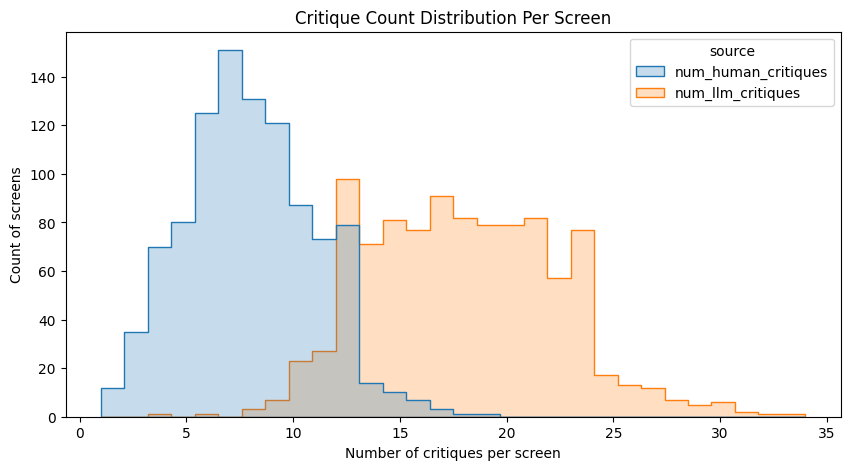

In [13]:
human_critiques_per_screen = (
    human_comments_long_df.groupby('screen_id').size().rename('num_human_critiques').reset_index()
)

llm_critiques_per_screen = (
    llm_critiques_long_df.groupby('screen_id').size().rename('num_llm_critiques').reset_index()
)

screen_volume_comparison_df = (
    human_critiques_per_screen
    .merge(llm_critiques_per_screen, on='screen_id', how='outer')
    .fillna(0)
)

screen_volume_comparison_df['num_human_critiques'] = screen_volume_comparison_df['num_human_critiques'].astype(int)
screen_volume_comparison_df['num_llm_critiques'] = screen_volume_comparison_df['num_llm_critiques'].astype(int)
screen_volume_comparison_df['count_diff_llm_minus_human'] = (
    screen_volume_comparison_df['num_llm_critiques'] - screen_volume_comparison_df['num_human_critiques']
)

volume_summary = pd.Series({
    'mean_human_critiques_per_screen': round(screen_volume_comparison_df['num_human_critiques'].mean(), 3),
    'mean_llm_critiques_per_screen': round(screen_volume_comparison_df['num_llm_critiques'].mean(), 3),
    'median_human_critiques_per_screen': float(screen_volume_comparison_df['num_human_critiques'].median()),
    'median_llm_critiques_per_screen': float(screen_volume_comparison_df['num_llm_critiques'].median()),
    'screens_with_zero_llm_critiques': int(screen_volume_comparison_df['num_llm_critiques'].eq(0).sum()),
    'screens_with_more_llm_than_human': int(screen_volume_comparison_df['count_diff_llm_minus_human'].gt(0).sum()),
    'screens_with_fewer_llm_than_human': int(screen_volume_comparison_df['count_diff_llm_minus_human'].lt(0).sum()),
    'screens_with_equal_counts': int(screen_volume_comparison_df['count_diff_llm_minus_human'].eq(0).sum()),
})

display(volume_summary.to_frame('value'))
display(screen_volume_comparison_df.sort_values('count_diff_llm_minus_human').head(10))
display(screen_volume_comparison_df.sort_values('count_diff_llm_minus_human', ascending=False).head(10))

plot_df = screen_volume_comparison_df.melt(
    id_vars='screen_id',
    value_vars=['num_human_critiques', 'num_llm_critiques'],
    var_name='source',
    value_name='num_critiques',
)

plt.figure(figsize=(10, 5))
sns.histplot(data=plot_df, x='num_critiques', hue='source', bins=30, element='step', stat='count', common_norm=False)
plt.title('Critique Count Distribution Per Screen')
plt.xlabel('Number of critiques per screen')
plt.ylabel('Count of screens')
plt.show()

## 4.3 Descriptive Breakdown By App Category

Use `app_category` to inspect whether some domains are more critique-dense than others.

Potential outputs:

- critique counts by category
- number of screens per category
- mean critiques per screen by category
- category-level differences between human and LLM critique volume


,app_category,human_num_screens,human_num_screen_tasks,human_num_critiques,llm_num_screens,llm_num_screen_tasks,llm_num_critiques,llm_guideline_reference_nonnull,human_mean_critiques_per_screen,llm_mean_critiques_per_screen,llm_minus_human_mean_critiques_per_screen
13,Health & Fitness,79,159,626,79,238,1496,1496,7.924051,18.936709,11.012658
21,Shopping,78,153,595,78,230,1318,1318,7.628205,16.897436,9.269231
24,Travel & Local,68,135,530,68,199,1208,1208,7.794118,17.764706,9.970588
22,Social,66,129,526,66,191,1129,1129,7.969697,17.106061,9.136364
23,Sports,64,127,555,64,190,1187,1187,8.671875,18.546875,9.875000
8,Education,61,121,477,61,180,1037,1037,7.819672,17.000000,9.180328
6,Communication,50,99,392,50,147,939,939,7.840000,18.780000,10.940000
9,Entertainment,48,96,354,48,143,842,841,7.375000,17.541667,10.166667
3,Books & Reference,46,91,373,46,136,785,785,8.108696,17.065217,8.956522
26,Weather,46,90,367,46,135,826,826,7.978261,17.956522,9.978261


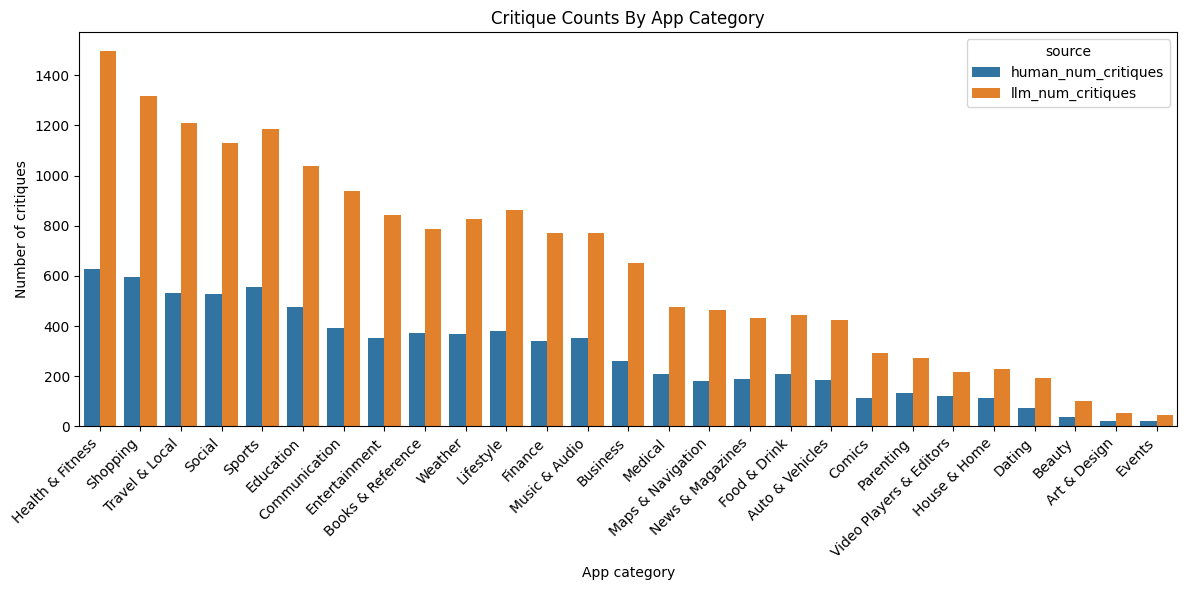

In [14]:
human_app_category_summary = (
    human_comments_long_df.groupby('app_category')
    .agg(
        human_num_screens=('screen_id', 'nunique'),
        human_num_screen_tasks=('screen_task_id', 'nunique'),
        human_num_critiques=('comment_id', 'count'),
    )
    .reset_index()
)

llm_with_category_df = llm_critiques_long_df.copy()

llm_app_category_summary = (
    llm_with_category_df.groupby('app_category')
    .agg(
        llm_num_screens=('screen_id', 'nunique'),
        llm_num_screen_tasks=('screen_task_id', 'nunique'),
        llm_num_critiques=('comment_id', 'count'),
        llm_guideline_reference_nonnull=('guideline_reference', lambda s: s.notna().sum()),
    )
    .reset_index()
)

app_category_summary_df = (
    human_app_category_summary
    .merge(llm_app_category_summary, on='app_category', how='outer')
    .fillna(0)
)

for col in [
    'human_num_screens', 'human_num_screen_tasks', 'human_num_critiques',
    'llm_num_screens', 'llm_num_screen_tasks', 'llm_num_critiques', 'llm_guideline_reference_nonnull'
]:
    app_category_summary_df[col] = app_category_summary_df[col].astype(int)

app_category_summary_df['human_mean_critiques_per_screen'] = (
    app_category_summary_df['human_num_critiques'] / app_category_summary_df['human_num_screens'].replace(0, np.nan)
)
app_category_summary_df['llm_mean_critiques_per_screen'] = (
    app_category_summary_df['llm_num_critiques'] / app_category_summary_df['llm_num_screens'].replace(0, np.nan)
)
app_category_summary_df['llm_minus_human_mean_critiques_per_screen'] = (
    app_category_summary_df['llm_mean_critiques_per_screen'] - app_category_summary_df['human_mean_critiques_per_screen']
)

app_category_summary_df = app_category_summary_df.sort_values('human_num_screens', ascending=False)
display(app_category_summary_df)

plot_category_df = app_category_summary_df.melt(
    id_vars='app_category',
    value_vars=['human_num_critiques', 'llm_num_critiques'],
    var_name='source',
    value_name='num_critiques',
)

plt.figure(figsize=(12, 6))
sns.barplot(data=plot_category_df, x='app_category', y='num_critiques', hue='source')
plt.title('Critique Counts By App Category')
plt.xlabel('App category')
plt.ylabel('Number of critiques')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### Prepare an App Category Review

Filters `target_category` screens, copies images, and generates screen/task summaries plus human and LLM comments. Exports all to an Excel file for review.

In [ ]:
from pathlib import Path
import shutil

target_category = "Health & Fitness"
category_short = "health_fitness"

review_dir = Path(f"./manual_review/{category_short}_llm_review")
images_dir = review_dir / "images"
review_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

used_screens_dir = Path("../../data/dataset/cleaned_dataset/used_dataset_screens")

health_screen_ids = sorted(
    human_comments_long_df.loc[
        human_comments_long_df["app_category"] == target_category, "screen_id"
    ].dropna().unique()
)

print("Health & Fitness screens:", len(health_screen_ids))

copied_rows = []
for screen_id in health_screen_ids:
    src = used_screens_dir / f"{screen_id}.jpg"
    dst = images_dir / f"{screen_id}.jpg"
    exists = src.exists()
    if exists and not dst.exists():
        shutil.copy2(src, dst)
    copied_rows.append({
        "screen_id": screen_id,
        "source_jpg": str(src.resolve()),
        "copied_jpg": str(dst.resolve()),
        "jpg_exists": exists,
    })
image_index_df = pd.DataFrame(copied_rows)

human_hf = human_comments_long_df[human_comments_long_df["app_category"] == target_category].copy()
llm_hf = llm_critiques_long_df[llm_critiques_long_df["app_category"] == target_category].copy()

screen_index_df = (
    pd.DataFrame({"screen_id": health_screen_ids})
    .merge(image_index_df, on="screen_id", how="left")
    .merge(
        human_hf.groupby("screen_id").agg(
            num_human_tasks=("screen_task_id", "nunique"),
            num_human_comments=("comment_id", "count"),
        ).reset_index(),
        on="screen_id", how="left",
    )
    .merge(
        llm_hf.groupby("screen_id").agg(
            num_llm_tasks=("screen_task_id", "nunique"),
            num_llm_comments=("comment_id", "count"),
        ).reset_index(),
        on="screen_id", how="left",
    )
    .fillna({"num_human_tasks": 0, "num_human_comments": 0, "num_llm_tasks": 0, "num_llm_comments": 0})
    .sort_values("screen_id")
)
for col in ["num_human_tasks", "num_human_comments", "num_llm_tasks", "num_llm_comments"]:
    screen_index_df[col] = screen_index_df[col].astype(int)

task_level_rows_df = (
    experts_df_shared.loc[
        experts_df_shared["screen_id"].isin(health_screen_ids),
        ["screen_id", "screen_task_id", "task", "app_category"]
    ]
    .drop_duplicates()
    .merge(
        human_hf.groupby(["screen_id", "screen_task_id"]).agg(num_human_comments=("comment_id", "count")).reset_index(),
        on=["screen_id", "screen_task_id"], how="left",
    )
    .merge(
        llm_hf.groupby(["screen_id", "screen_task_id"]).agg(num_llm_comments=("comment_id", "count")).reset_index(),
        on=["screen_id", "screen_task_id"], how="left",
    )
    .fillna({"num_human_comments": 0, "num_llm_comments": 0})
    .sort_values(["screen_id", "screen_task_id"])
)
for col in ["num_human_comments", "num_llm_comments"]:
    task_level_rows_df[col] = task_level_rows_df[col].astype(int)

human_comments_review_df = human_hf[[
    "screen_id", "screen_task_id", "task", "app_category", "comment_id", "comment_label",
    "observed_issue", "expected_standard", "suggested_fix", "missing_parts"
]].copy().sort_values(["screen_id", "screen_task_id", "comment_id"])
human_comments_review_df["missing_parts"] = human_comments_review_df["missing_parts"].apply(
    lambda x: " | ".join(map(str, x)) if isinstance(x, list) else ""
)

llm_comments_review_df = llm_hf[[
    "screen_id", "screen_task_id", "task", "app_category", "model_name", "comment_id",
    "observed_issue", "expected_standard", "suggested_fix", "guideline_reference"
]].copy().sort_values(["screen_id", "screen_task_id", "comment_id"])

excel_path = review_dir / "health_fitness_review.xlsx"
with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    screen_index_df.to_excel(writer, sheet_name="screen_index", index=False)
    task_level_rows_df.to_excel(writer, sheet_name="task_level_rows", index=False)
    human_comments_review_df.to_excel(writer, sheet_name="human_comments", index=False)
    llm_comments_review_df.to_excel(writer, sheet_name="llm_comments", index=False)

print("Saved review folder:", review_dir.resolve())
print("Saved workbook:", excel_path.resolve())
print("Copied JPGs:", int(image_index_df["jpg_exists"].sum()), "/", len(image_index_df))


Health & Fitness screens: 79
Saved review folder: C:\Users\mahmo\OneDrive - The University of Western Ontario\Desktop\Western_University\Thesis\Project\code\analysis\manual_review\health_fitness_llm_review
Saved workbook: C:\Users\mahmo\OneDrive - The University of Western Ontario\Desktop\Western_University\Thesis\Project\code\analysis\manual_review\health_fitness_llm_review\health_fitness_review.xlsx
Copied JPGs: 79 / 79


# 5. Screen-Level Candidate Pair Construction

This section will generate the candidate comparison universe.

Instead of pairing critiques within the same task, pair all human and LLM critiques that belong to the same `screen_id`.


## 5.1 Build Within-Screen Human-LLM Pairs

For each screen:

- take all standardized human critiques on that screen
- take all standardized LLM critiques on that screen
- form all human-LLM pairs within the screen

Each pair should retain enough metadata to trace both comments back to their source rows.


In [ ]:
from utils.comment_matching_utils import build_standardized_pairs

screen_level_candidate_pairs = build_standardized_pairs(
    human_comments_long_df,
    llm_critiques_long_df,
    pair_id_prefix='PAIR',
)

pair_count_summary = pd.Series({
    'num_candidate_pairs': len(screen_level_candidate_pairs),
    'num_screens': screen_level_candidate_pairs['screen_id'].nunique(),
    'num_unique_left_comments': screen_level_candidate_pairs['left_comment_id'].nunique(),
    'num_unique_right_comments': screen_level_candidate_pairs['right_comment_id'].nunique(),
})

display(pair_count_summary.to_frame('value'))
screen_level_candidate_pairs.head(3)


## 5.2 Define Pair Metadata

The candidate pair table should use one shared left-right schema.

Each pair should include:

- `pair_id`
- `screen_id`
- `left_comment_id`, `right_comment_id`
- `left_source_type`, `right_source_type`
- `left_screen_task_id`, `right_screen_task_id`
- `left_task`, `right_task`
- `left_observed_issue`, `right_observed_issue`
- `left_expected_standard`, `right_expected_standard`
- `left_suggested_fix`, `right_suggested_fix`
- `left_match_text`, `right_match_text`

Optional source-specific fields can be carried through when helpful for inspection or later analysis.


In [ ]:
screen_pair_sizes_df = (
    screen_level_candidate_pairs.groupby('screen_id')
    .agg(
        num_left_comments=('left_comment_id', 'nunique'),
        num_right_comments=('right_comment_id', 'nunique'),
        num_pairs=('pair_id', 'count'),
    )
    .reset_index()
)

screen_pair_sizes_df['expected_pairs_from_counts'] = (
    screen_pair_sizes_df['num_left_comments'] * screen_pair_sizes_df['num_right_comments']
)

assert (screen_pair_sizes_df['num_pairs'] == screen_pair_sizes_df['expected_pairs_from_counts']).all(), (
    'Within-screen pair counts do not match the expected cartesian product.'
)

display(screen_pair_sizes_df.sort_values('num_pairs', ascending=False).head(10))
screen_level_candidate_pairs.head(3)

# 6. Embedding Similarity Retrieval

This section will implement the first matching stage using sentence embeddings.


## 6.1 Embed `observed_issue` Text

Use:

- `SentenceTransformer("all-mpnet-base-v2")`

The embedding input should be the `observed_issue` text for both human and LLM critiques, with only minimal inline preparation such as string casting and whitespace trimming.


In [ ]:
from utils.comment_matching_utils import (
    DEFAULT_EMBEDDING_MODEL_NAME,
    DEFAULT_REVIEW_MODEL,
    build_standard_preview_df,
    identify_review_needed,
    load_embedding_model,
    parse_semantic_review_results_jsonl,
    prepare_review_chunks,
    score_standardized_pairs,
    select_similarity_band,
    write_jsonl,
)

EMBEDDING_MODEL_NAME = DEFAULT_EMBEDDING_MODEL_NAME
embedding_model = load_embedding_model(EMBEDDING_MODEL_NAME)
combined_comments_df = pd.concat([human_comments_long_df, llm_critiques_long_df], ignore_index=True)
print('Loaded embedding model:', EMBEDDING_MODEL_NAME)


## 6.2 Compute Cosine Similarity

For each within-screen human-LLM pair:

- compute cosine similarity between the two embeddings
- store the score in the candidate pair table
- inspect the distribution of similarity values


In [ ]:
screen_level_candidate_pairs_scored, comment_embeddings_df = score_standardized_pairs(
    screen_level_candidate_pairs,
    combined_comments_df,
    embedding_model=embedding_model,
)

similarity_summary = screen_level_candidate_pairs_scored['cosine_similarity'].describe().round(4)
print('Embedding rows:', len(comment_embeddings_df))
print('Scored candidate pairs:', len(screen_level_candidate_pairs_scored))
display(similarity_summary.to_frame('value'))
display(
    build_standard_preview_df(
        screen_level_candidate_pairs_scored,
        include_score=True,
        sort_cols=['cosine_similarity', 'screen_id'],
        ascending=[False, True],
        limit=10,
    )
)


## 6.3 Define Threshold Bands

Use the similarity distribution to define working bands such as:

- high-similarity pairs that are likely matches
- mid-band pairs that require review
- low-similarity pairs that are likely non-matches

The exact thresholds can be finalized during implementation after inspecting the score distribution.


In [ ]:
SEMANTIC_SIMILARITY_THRESHOLD = 0.88
BATCH_REVIEW_LOWER_BOUND = 0.50

high_similarity_pairs_df = select_similarity_band(
    screen_level_candidate_pairs_scored,
    score_col='cosine_similarity',
    lower_bound=SEMANTIC_SIMILARITY_THRESHOLD,
    sort_cols=['cosine_similarity', 'screen_id'],
    ascending=[False, True],
)

review_band_pairs_df = select_similarity_band(
    screen_level_candidate_pairs_scored,
    score_col='cosine_similarity',
    lower_bound=BATCH_REVIEW_LOWER_BOUND,
    upper_bound=SEMANTIC_SIMILARITY_THRESHOLD,
    sort_cols=['screen_id', 'cosine_similarity'],
    ascending=[True, False],
).reset_index(drop=True)

low_similarity_pairs_df = select_similarity_band(
    screen_level_candidate_pairs_scored,
    score_col='cosine_similarity',
    upper_bound=BATCH_REVIEW_LOWER_BOUND,
    sort_cols=['screen_id', 'cosine_similarity'],
    ascending=[True, False],
).reset_index(drop=True)

threshold_band_summary_df = pd.DataFrame([
    {'band': 'high_similarity_auto_match', 'rows': len(high_similarity_pairs_df)},
    {'band': 'review_band', 'rows': len(review_band_pairs_df)},
    {'band': 'low_similarity', 'rows': len(low_similarity_pairs_df)},
])

print('Threshold:', SEMANTIC_SIMILARITY_THRESHOLD)
print('Review lower bound:', BATCH_REVIEW_LOWER_BOUND)
display(threshold_band_summary_df)
display(build_standard_preview_df(review_band_pairs_df, include_score=True, limit=10))


# 7. OpenAI Adjudication For Uncertain Pairs

This section will implement the second matching stage for uncertain semantic pairs.

The design should mirror the conservative review workflow used in the human-reference preparation notebook.


## 7.1 Prepare Review Candidates

Select only the uncertain similarity-band pairs for OpenAI review.

This keeps the review set focused and avoids unnecessary API usage on clearly matching or clearly non-matching pairs.


In [ ]:
REVIEW_OUTPUT_DIR = Path('../../data/dataset/cleaned_dataset/human_critiques') / 'llm_comment_matching'
REVIEW_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BATCH_MODEL = DEFAULT_REVIEW_MODEL
BATCH_CHUNK_SIZE = 50
CURRENT_BATCH_CHUNK_INDEX = 0
REVIEW_CONFIDENCE_THRESHOLD = 0.90

review_band_pairs_df = review_band_pairs_df.copy()
review_band_pairs_df['left_text'] = review_band_pairs_df['left_observed_issue']
review_band_pairs_df['right_text'] = review_band_pairs_df['right_observed_issue']

review_band_pairs_df['custom_id'] = review_band_pairs_df.apply(
    lambda row: f"semantic_pair::{row['left_comment_id']}::{row['right_comment_id']}",
    axis=1,
)

semantic_review_requests, semantic_review_request_chunks, semantic_review_candidate_chunks = prepare_review_chunks(
    review_band_pairs_df,
    chunk_size=BATCH_CHUNK_SIZE,
    custom_id_col='custom_id',
    left_id_col='left_comment_id',
    right_id_col='right_comment_id',
    screen_id_col='screen_id',
    left_text_col='left_text',
    right_text_col='right_text',
    left_screen_task_id_col='left_screen_task_id',
    right_screen_task_id_col='right_screen_task_id',
    left_source_col='left_source_type',
    right_source_col='right_source_type',
    model=BATCH_MODEL,
)

review_prep_summary = pd.Series({
    'review_candidates': len(review_band_pairs_df),
    'request_chunks': len(semantic_review_request_chunks),
    'chunk_size': BATCH_CHUNK_SIZE,
    'current_chunk_index': CURRENT_BATCH_CHUNK_INDEX,
})

display(review_prep_summary.to_frame('value'))


## 7.2 Build OpenAI Review Prompt

The OpenAI prompt should compare two critiques written about the same screen and ask whether they describe the same issue, one contains the other, partially overlap, or are different.

For now, the comparison should be based on `observed_issue` only.

The schema should be structured and conservative so the results can be merged back into the final match table cleanly.


In [ ]:
CURRENT_BATCH_REQUESTS_PATH = REVIEW_OUTPUT_DIR / f'semantic_match_batch_requests_chunk_{CURRENT_BATCH_CHUNK_INDEX:03d}.jsonl'
CURRENT_BATCH_RESULTS_PATH = REVIEW_OUTPUT_DIR / f'semantic_match_batch_results_chunk_{CURRENT_BATCH_CHUNK_INDEX:03d}.jsonl'

if semantic_review_request_chunks:
    current_chunk_requests = semantic_review_request_chunks[CURRENT_BATCH_CHUNK_INDEX]
    current_chunk_candidates = pd.DataFrame(semantic_review_candidate_chunks[CURRENT_BATCH_CHUNK_INDEX])
    write_jsonl(current_chunk_requests, CURRENT_BATCH_REQUESTS_PATH)

    print('Current chunk index:', CURRENT_BATCH_CHUNK_INDEX)
    print('Requests in current chunk:', len(current_chunk_requests))
    print('Chunk request path:', CURRENT_BATCH_REQUESTS_PATH)
    display(build_standard_preview_df(current_chunk_candidates, include_score=True, limit=10))
else:
    current_chunk_requests = []
    current_chunk_candidates = pd.DataFrame()
    print('No review-band pairs to send for OpenAI adjudication.')


In [ ]:
from openai import OpenAI
from utils.openai_batch_manager import OpenAIBatchManager

batch_client = OpenAI()
batch_manager = OpenAIBatchManager(batch_client, REVIEW_OUTPUT_DIR / 'openai_semantic_batch', 'semantic_match_review')
print('Batch manager ready.')


## 7.3 Pilot Review Then Full Review

Follow the same operational pattern used in the reference notebook:

- prepare a small pilot batch first
- inspect the returned judgments
- adjust prompt/schema if needed
- then run the full uncertain-pair review set


In [ ]:
# Optional run cell: upload the current chunk, create the batch, and retrieve the output once complete.
# Run this only when you are ready to submit the current chunk.

if current_chunk_requests:
    current_input_file_id = batch_manager.upload_file(CURRENT_BATCH_REQUESTS_PATH)
    current_batch = batch_manager.create_batch(current_input_file_id)
    current_batch_id = getattr(current_batch, 'id', None) if current_batch else None

    print('Current input file id:', current_input_file_id)
    print('Current batch id:', current_batch_id)
else:
    print('No current chunk requests to submit.')


In [ ]:
# Optional status-check cell after submission.
if 'current_batch_id' in globals() and current_batch_id:
    state, current_batch_status = batch_manager.check_batch(current_batch_id, verbose=True)
    print('Resolved state:', state)
else:
    print('No current_batch_id found. Submit a chunk first.')


In [ ]:
# Optional retrieval-and-parse cell after the batch completes.
if 'current_batch_id' in globals() and current_batch_id:
    current_output_path = batch_manager.retrieve_batch_output(
        batch_id=current_batch_id,
        base_name=f'semantic_match_batch_results_chunk_{CURRENT_BATCH_CHUNK_INDEX:03d}'
    )
    print('Current chunk batch results saved to:', current_output_path)
else:
    current_output_path = None
    print('No current_batch_id found. Submit and complete a chunk first.')


In [ ]:
if current_output_path and Path(current_output_path).exists():
    current_chunk_results_df = parse_semantic_review_results_jsonl(
        current_output_path,
        current_chunk_candidates,
        left_id_col='left_comment_id',
        right_id_col='right_comment_id',
        include_candidate_columns=[
            'screen_id', 'left_screen_task_id', 'right_screen_task_id',
            'left_text', 'right_text', 'cosine_similarity'
        ],
    )

    review_needed_df = identify_review_needed(
        current_chunk_results_df,
        confidence_threshold=REVIEW_CONFIDENCE_THRESHOLD,
    )

    display(current_chunk_results_df.head(10))
    print('Rows needing manual review in current chunk:', len(review_needed_df))
    display(review_needed_df)
else:
    print('Current chunk output file not found yet. Run the retrieval cell first.')


# 8. Final Match Table

This section will combine embedding similarity outputs and OpenAI review decisions into a final, auditable match table.


## 8.1 Consolidate Match Decisions

Combine all available evidence for each candidate pair:

- screen-level pair identity
- similarity score
- threshold-band classification
- OpenAI review output if applicable
- final match decision


## 8.2 Derive Coverage Flags

From the consolidated pair decisions, derive:

- whether each human critique is covered by any LLM critique
- whether each LLM critique aligns with any human critique
- best-match links where one pair should be treated as the primary alignment


# 9. Evaluation Metrics

This section will summarize how well the LLM critiques align with the human reference once the final match table is available.


## 9.1 Human Coverage Metrics

Measure how often the LLM captures the human issues.

Suggested outputs:

- overall human coverage rate
- coverage by screen
- coverage by app category
- coverage by presence or absence of `missing_parts`


## 9.2 LLM Alignment Metrics

Measure how often the generated LLM critiques correspond to the human reference.

Suggested outputs:

- overall LLM alignment rate
- unmatched LLM critique rate
- alignment by screen
- alignment by app category


## 9.3 Count And Similarity Summaries

Add descriptive summaries such as:

- critique count differences between human and LLM per screen
- mean and median similarity of matched pairs
- screens with strongest and weakest observed alignment


# 10. Guideline Reference Analysis

This section will analyze `guideline_reference` usage in the LLM critiques independently and in relation to human alignment.


## 10.1 Guideline Reference Coverage

Measure how often `guideline_reference` is present in the LLM critique table.

Possible summaries:

- proportion of critiques with a non-empty guideline reference
- proportion by screen
- proportion by app category


## 10.2 Guideline Reference Frequency

Summarize the most common guideline references used by the model.

This may require some normalization later if the references vary in wording or citation style.


## 10.3 Guideline Reference And Match Quality

Explore whether critiques that include a guideline reference are more likely to match the human reference.

This can remain exploratory in the first implementation pass.


# 11. Qualitative Examples

This section will present hand-inspected examples that help interpret the quantitative results.


## 11.1 Strong Matches

Show examples where the LLM clearly captures the same issue as the human reference.


## 11.2 Partial Overlaps

Show examples where the LLM and human critiques are related but differ in granularity, detail, or framing.


## 11.3 Human-Only And LLM-Only Cases

Show examples of:

- human critiques missed by the LLM
- LLM critiques without a convincing human counterpart


# 12. Save Outputs

This final section will export the key intermediate and final artifacts so the notebook can be resumed or extended efficiently.


## 12.1 Save Analysis Tables

Save the long-form tables, candidate-pair tables, review outputs, and final match table.


## 12.2 Save Summary Outputs

Save compact summaries such as:

- per-screen metrics
- app-category summaries
- guideline-reference frequency tables
- any thesis-ready CSV tables or figures
